<a href="https://colab.research.google.com/github/JonathanDrivas/Calibration-Detector/blob/main/S05_LAB03_Yolande_Xia_xx2579.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB03: In-class and take-home route



## In class (60 minutes)



### t01_land_build: Land sources and build project

Start: 🧪 In-class checkpoint 1 | Land the sources and build the project | 13 minutes

Open sources.yml and stg_lines.sql, run provided seed and build cells, and confirm staging views compile cleanly.

Files: data/guided/orders.csv, data/guided/lines.csv, data/guided/products.csv, data/guided/customers.csv

Check: Clean dbt build output confirming staged models built with zero compilation errors.

Save: work/S05/checkpoints/checkpoint_01.json

Resume: test In-class checkpoint 2 | Read the lineage as evidence | 14 minutes

Submit: No submission required for in-class verification checkpoint



### t02_lineage_trace: Read lineage as evidence and practice model edit

Start: 🧪 In-class checkpoint 2 | Read the lineage as evidence | 14 minutes

Inspect manifest.json lineage table, type product_id filter in practice model, and run practice view check.

Files: data/guided/products.csv

Check: Successful dbt run displaying exactly four rows in the practice_products view.

Save: work/S05/checkpoints/checkpoint_02.json

Resume: 🧪 In-class checkpoint 3 | Push a defect through the gate, then recover | 20 minutes

Submit: No submission required for in-class verification checkpoint



### t03_defect_recovery: Push defect through gate and verify recovery

Start: 🧪 In-class checkpoint 3 | Push a defect through the gate, then recover | 20 minutes

Execute controlled defect update in raw_lines, inspect failing test output, and verify automated finally reset.

Files: data/guided/lines.csv

Check: Log output confirming non-negative test failed and subsequent reset rebuild passed.

Save: work/S05/checkpoints/checkpoint_03.json

Resume: 🧪 In-class checkpoint 4 | Answer the release question | 13 minutes

Submit: No submission required for in-class verification checkpoint



### t04_release_reply: Answer the release question and record evidence

Start: 🧪 In-class checkpoint 4 | Answer the release question | 13 minutes

Draft 150-220 word reply to Daniel Okafor citing lineage paths, tested integrity rules, and release conditions.

Files: data/guided/lines.csv, data/guided/orders.csv

Check: Written memo response evaluating scheduling decision with explicit tested rule boundaries.

Save: work/S05/checkpoints/checkpoint_04.json

Resume: Take-home | LAB-03

Submit: No submission required for in-class verification checkpoint



## Take home (60 minutes)



### t05_independent_mart: Build category demand mart on independent data

Start: Take-home | LAB-03

Create mart_category_daily.sql, singular tests, and schema.yml tests against gc3260_l03_ind schema.

Files: data/independent/orders.csv, data/independent/lines.csv, data/independent/products.csv, data/independent/customers.csv

Check: dbt build and docs generate pass cleanly against independent retail records.

Save: work/S05/dbt_independent/models/marts/mart_category_daily.sql

Resume: Submit three files

Submit: Submit notebook, work ZIP, and memo PDF by Tuesday, October 6, 2026, 11:59 PM ET



## If you need to catch up

If the Snowflake connection resets, renew your assigned student token, rerun the setup cells, and execute dbt build to restore schema state.




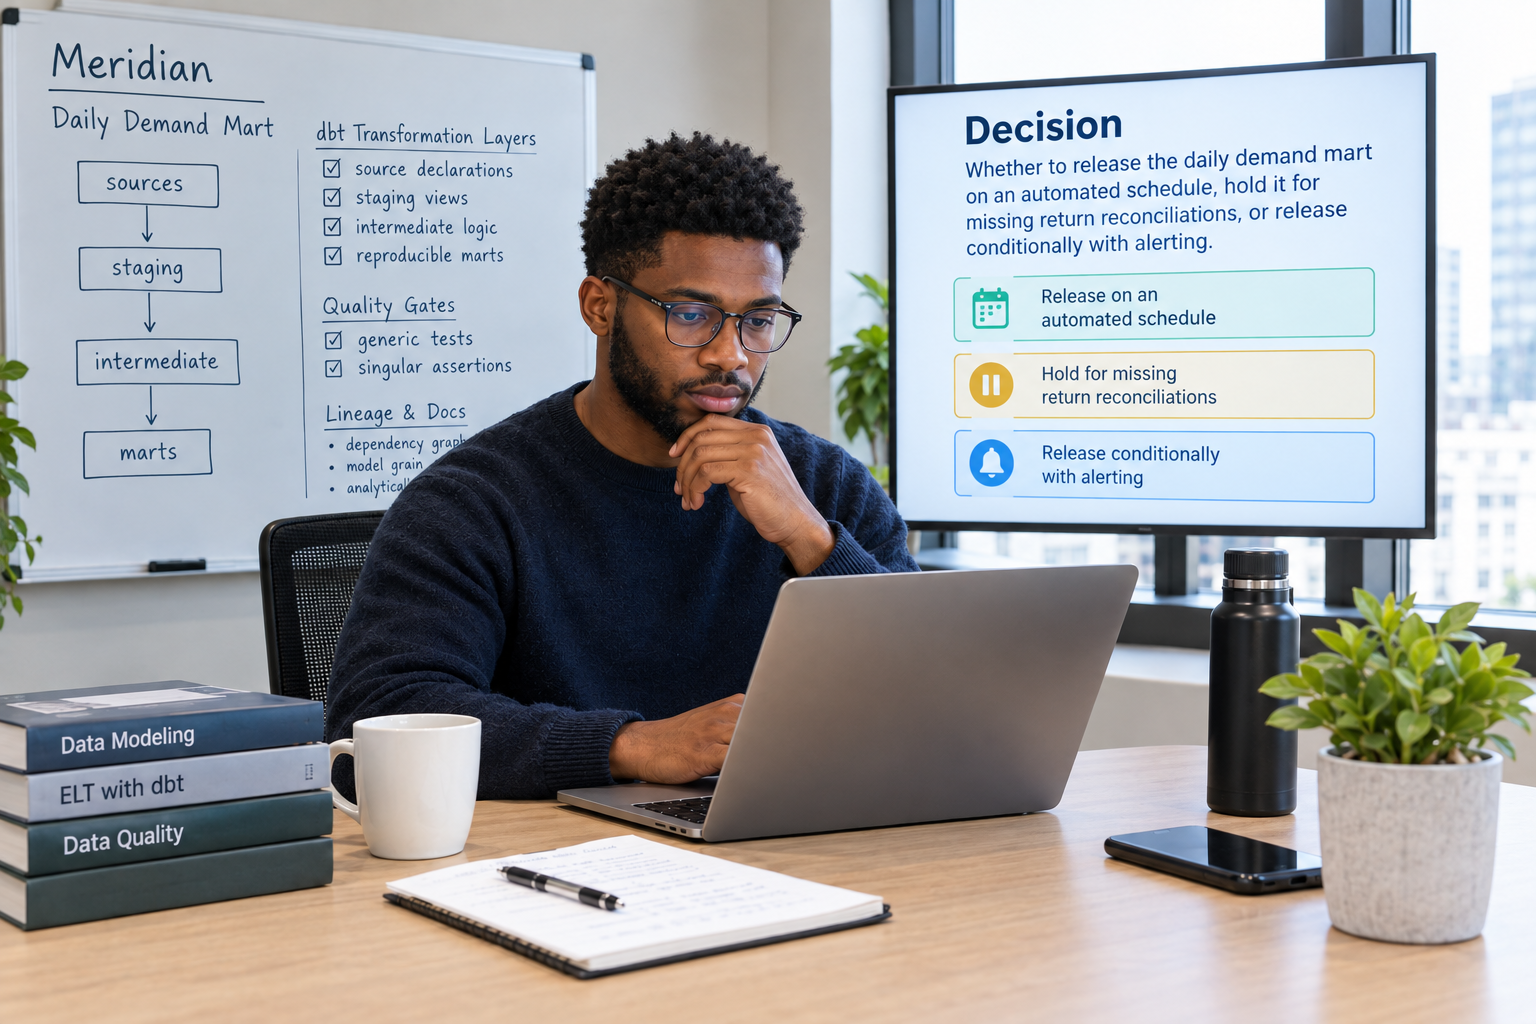

*Case illustration; use the supplied data for analysis.*


# 💻 GC3260 | Session 05 | Colab, Jupyter, or VS Code

**Recommended default: Google Colab with a standard CPU runtime.** The same notebook also runs locally in Anaconda Jupyter/JupyterLab or the VS Code notebook interface.

## Start here

1. 🎯 Save your own notebook copy before entering answers. Use **File > Save a copy in Drive**, or download your edited `.ipynb` file before closing. If your first name is Jane, last name is Doe, and NYU NetID (the ID used in your NYU email) is `jd1234`, use `S05_LAB03_Jane_Doe_jd1234.ipynb`. Replace those example values with your own.

2. Run course-setup steps **1A through 1H** in order, then the connect steps **2A, 2B and 2C**. Each code cell has one job and prints progress. Wait for **READY**; package preparation may take a few minutes on the first run. If step 2B shows a key reminder, type **y** to paste your keys or **n** to stop.

3. 🧭 Complete the original activity below. Treat each SQL and dbt cell as a first encounter: read its purpose, syntax notes, expected output, interpretation prompt, and recovery advice. Write only the requested SQL, dbt files and explanations. Supporting Python is supplied.

4. 📦 Save the notebook and use **Download work backup** at the end. Your Snowflake database persists between sessions. Colab runtime files are temporary; local project files remain on your computer.

## Choose your environment

This notebook includes its data and support files. For Colab, open it from the instructor's Google Drive hub and choose **File > Save a copy in Drive** before working. For Anaconda or VS Code, save or open the notebook anywhere inside the complete GC3260 project folder so the setup can find the course root and local `.env`. Keep your personal copy and work backup in your own course folder. A shortcut to the instructor's master is not your own editable copy.

## 🔐 Course keys and privacy

From LAB-02 onward the course database is **Snowflake**. You sign in as your own assigned student user. You never need, and must never ask for, the instructor's login. Two keys are required: `GC3260_SNOWFLAKE_USER` and `GC3260_SNOWFLAKE_TOKEN`.

**Default route, Google Colab:** open Colab's **Secrets** panel (key icon). Add both keys from your private credential sheet and switch on **Notebook access** for each.

**Local route, Anaconda Jupyter/JupyterLab or VS Code:** save a file named exactly `.env` inside the complete GC3260 project folder. The project root is preferred.

```text
GC3260_SNOWFLAKE_USER=your_assigned_snowflake_user
GC3260_SNOWFLAKE_TOKEN=your_assigned_access_token
```

The token is a long string that works like a password for this course only. Your private database, role and warehouse are already attached to your user, so you do not enter them. Your LAB-01 Neon keys are not used here; leave them in place for LAB-01.

Never paste a key into a code cell, Markdown cell, screenshot, memo, or submission. The only safe places are Colab Secrets, your local `.env`, or the hidden paste box that step 2B opens. The instructor administrator credential is never placed in this notebook or `.env`.

**Forgot to set up your keys?** Step 2B notices, shows a reminder, and asks **y** or **n**. Answer **y** and paste each value into the hidden box that appears; the lab then runs normally for this session. Set the keys up permanently afterwards so you are not asked again.

**Existing work:** after the setup cells, use the optional restore cell before continuing. A new course release has a separate folder and does not overwrite an older release.

### 1A: Detect the notebook runtime

**Code category:** Python environment check, not SQL

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 1/8 complete and identifies Colab or local Jupyter/VS Code.

In [16]:
#@title 1A. Detect the notebook runtime (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
import base64, hashlib, io, os, sys, zipfile
from pathlib import Path
try:
    import google.colab  # Colab does not guarantee that COLAB_RELEASE_TAG is present.
    _GC3260_RUNTIME = 'colab'
except ImportError:
    _GC3260_RUNTIME = 'local'
print(f'SETUP 1/8 complete: {_GC3260_RUNTIME} Python runtime detected.')

SETUP 1/8 complete: colab Python runtime detected.


### 1B: Create the course-file workspace plan

**Code category:** Python variable assignment and path planning, not SQL

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 2/8 complete and names the bounded course project folder.

In [17]:
#@title 1B. Plan the course-file workspace (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
# Four small text parts are safer for a browser than one very large code cell.
_GC3260_BUNDLE_SHA256 = '39018672b25025fdb5e5470df905de181eef0b42e3cfb7446b174817566e5452'
_GC3260_SAME_BUNDLE = globals().get('_GC3260_LOADED_BUNDLE_SHA256') == _GC3260_BUNDLE_SHA256
if (not _GC3260_SAME_BUNDLE
        or len(globals().get('_GC3260_BUNDLE_PARTS', [])) != 4):
    _GC3260_BUNDLE_PARTS = [None] * 4
_GC3260_LOADED_BUNDLE_SHA256 = _GC3260_BUNDLE_SHA256
_GC3260_LAUNCH_DIR = Path.cwd().resolve()
if _GC3260_RUNTIME == 'colab':
    ROOT = Path('/content/gc3260_39018672b250')
    _GC3260_PROJECT_SEARCH_ROOT = ROOT
else:
    # Prefer the complete course folder when the notebook is opened anywhere inside it.
    _GC3260_EXISTING_ROOT = next(
        (p for p in [_GC3260_LAUNCH_DIR, *_GC3260_LAUNCH_DIR.parents]
         if (p / '.course-root').exists()),
        None,
    )
    if not (_GC3260_SAME_BUNDLE and isinstance(globals().get('_GC3260_PROJECT_SEARCH_ROOT'), Path)):
        _GC3260_PROJECT_SEARCH_ROOT = _GC3260_EXISTING_ROOT or _GC3260_LAUNCH_DIR
    ROOT = _GC3260_EXISTING_ROOT or (_GC3260_LAUNCH_DIR / 'gc3260_39018672b250')
os.environ['GC3260_PROJECT_ROOT'] = str(_GC3260_PROJECT_SEARCH_ROOT)
print(f'SETUP 2/8 complete: workspace planned at {ROOT}.')
print(f'Key search is limited to: {_GC3260_PROJECT_SEARCH_ROOT}')

SETUP 2/8 complete: workspace planned at /content/gc3260_39018672b250.
Key search is limited to: /content/gc3260_39018672b250


### 1C: Load course-file part 1 of 4

**Code category:** Python text assignment, not SQL and not a database load

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 3/8 complete.

In [18]:
#@title 1C. Load course files, part 1 of 4 (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
if '_GC3260_BUNDLE_PARTS' not in globals():
    raise RuntimeError('Run setup step 1A first, then continue in order.')
print('SETUP 3/8: loading course-file part 1 of 4...', flush=True)
_GC3260_BUNDLE_PARTS[0] = '...'
print('SETUP 3/8 complete: course-file part 1 of 4 is ready.')

SETUP 3/8: loading course-file part 1 of 4...
SETUP 3/8 complete: course-file part 1 of 4 is ready.


### 1D: Load course-file part 2 of 4

**Code category:** Python text assignment, not SQL and not a database load

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 4/8 complete.

In [19]:
#@title 1D. Load course files, part 2 of 4 (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
if '_GC3260_BUNDLE_PARTS' not in globals():
    raise RuntimeError('Run setup step 1A first, then continue in order.')
print('SETUP 4/8: loading course-file part 2 of 4...', flush=True)
_GC3260_BUNDLE_PARTS[1] = '...'
print('SETUP 4/8 complete: course-file part 2 of 4 is ready.')

SETUP 4/8: loading course-file part 2 of 4...
SETUP 4/8 complete: course-file part 2 of 4 is ready.


### 1E: Load course-file part 3 of 4

**Code category:** Python text assignment, not SQL and not a database load

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 5/8 complete.

In [20]:
#@title 1E. Load course files, part 3 of 4 (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
if '_GC3260_BUNDLE_PARTS' not in globals():
    raise RuntimeError('Run setup step 1A first, then continue in order.')
print('SETUP 5/8: loading course-file part 3 of 4...', flush=True)
_GC3260_BUNDLE_PARTS[2] = '...'
print('SETUP 5/8 complete: course-file part 3 of 4 is ready.')

SETUP 5/8: loading course-file part 3 of 4...
SETUP 5/8 complete: course-file part 3 of 4 is ready.


### 1F: Load course-file part 4 of 4

**Code category:** Python text assignment, not SQL and not a database load

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 6/8 complete.

In [21]:
#@title 1F. Load course files, part 4 of 4 (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
if '_GC3260_BUNDLE_PARTS' not in globals():
    raise RuntimeError('Run setup step 1A first, then continue in order.')
print('SETUP 6/8: loading course-file part 4 of 4...', flush=True)
_GC3260_BUNDLE_PARTS[3] = '...'
print('SETUP 6/8 complete: course-file part 4 of 4 is ready.')

SETUP 6/8: loading course-file part 4 of 4...
SETUP 6/8 complete: course-file part 4 of 4 is ready.


### 1G: Verify and unpack the course files

**Code category:** Python file integrity and local file I/O, not database DDL

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 7/8 complete and confirms the bundle was verified.

In [22]:
#@title 1G. Verify and unpack course files (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
if '_GC3260_BUNDLE_PARTS' not in globals():
    raise RuntimeError('Run setup steps 1A through 1F first, then run this cell.')
if any(part is None for part in _GC3260_BUNDLE_PARTS):
    raise RuntimeError('A course-file part is missing. Run setup steps 1A through 1F in order, then rerun 1G.')
print('SETUP 7/8: verifying and unpacking the course files...', flush=True)
raw = base64.b64decode(''.join(_GC3260_BUNDLE_PARTS), validate=True)
assert hashlib.sha256(raw).hexdigest() == _GC3260_BUNDLE_SHA256, "The notebook download is incomplete. Download it again."
ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
    for entry in archive.infolist():
        target = (ROOT / entry.filename).resolve()
        if ROOT.resolve() not in target.parents: raise ValueError("Unexpected course file path")
        # Never replace files that have already been created or edited in this runtime.
        if not target.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(archive.read(entry))
print('SETUP 7/8 complete: course files verified and unpacked.')

SETUP 7/8: verifying and unpacking the course files...
SETUP 7/8 complete: course files verified and unpacked.


### 1H: Open the course helpers

**Code category:** Python module import, not SQL

**Why this step exists:** This setup task prepares the learning environment. It does not change business data or answer a lab question.

**Success check:** The output says SETUP 8/8 complete and directs you to step 2A.

In [23]:
#@title 1H. Open the course helpers (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
if 'ROOT' not in globals() or not ROOT.exists():
    raise RuntimeError('Run setup steps 1A through 1G first, then run this cell.')
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
# Prevent imports from a different release in a previously used runtime.
for name in ['portable_runtime','coursekit','lab_runner','pipeline']:
    old = sys.modules.get(name)
    if old is not None and getattr(old,'__file__',None) and ROOT not in Path(old.__file__).resolve().parents:
        del sys.modules[name]
print('SETUP 8/8: opening course helpers; this may take a moment...', flush=True)
import portable_runtime as pr
print('SETUP 8/8 complete: course helpers are ready.')
print('Course files found. Continue with step 2A.')

SETUP 8/8: opening course helpers; this may take a moment...
SETUP 8/8 complete: course helpers are ready.
Course files found. Continue with step 2A.


### 2A: Prepare the Snowflake tools

**Code category:** Python package installation, not SQL

**Why this step exists:** The notebook installs the database driver into its own Python. Nothing is installed on your laptop when you use Colab.

**Success check:** The output says STEP 2A complete. The first run can take a few minutes while the circle spins.

In [24]:
#@title 2A. Prepare the Snowflake tools (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
pr.prepare_packages('snowflake', dbt=True)

STEP 2A complete: packages ready for Snowflake (LAB-02 onward) with dbt. Release 2026.09.24-snowflake2-scaffold


['dbt-core', 'dbt-snowflake', 'snowflake-connector-python']

### 2B: Find your course keys

**Code category:** Python credential lookup, not SQL. No value is displayed.

**Why this step exists:** The notebook looks in Colab Secrets, or in your local `.env` file. If a key is missing, a reminder appears and a box asks **y** or **n**. Type **y** to paste the missing values into hidden boxes so the lab can still run for this session. Type **n** to stop and set the keys up first. Pasted values are never shown, saved in the notebook, or included in a backup.

**Success check:** The output says STEP 2B complete and lists where `GC3260_SNOWFLAKE_USER` and `GC3260_SNOWFLAKE_TOKEN` were found.

In [25]:
#@title 2B. Find your course keys; paste them if reminded (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
pr.find_keys('snowflake', project_root=os.environ.get('GC3260_PROJECT_ROOT'))

STEP 2B complete: all required Snowflake (LAB-02 onward) keys are available. No value was displayed.
  GC3260_SNOWFLAKE_USER: Colab Secrets (key icon)
  GC3260_SNOWFLAKE_TOKEN: Colab Secrets (key icon)


{'GC3260_SNOWFLAKE_USER': 'Colab Secrets (key icon)',
 'GC3260_SNOWFLAKE_TOKEN': 'Colab Secrets (key icon)'}

### 2C: Connect to Snowflake and confirm your identity

**Code category:** Database session check. It reads identity only and changes no data.

**Why this step exists:** Database access is scoped by your assigned user and its privileges. This check proves which identity the rest of the notebook will use. After a long pause, the next database cell automatically reconnects using the student token still available in this runtime. If the token expired or the runtime restarted, renew the student token in Colab Secrets or local `.env`, then rerun 2B and 2C.

**Success check:** The output says READY and shows your own user, role and database. It never shows a token or password.

In [26]:
#@title 2C. Connect to Snowflake (run unchanged)
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
pr.connect_course_database('snowflake')

READY: connected with your assigned student-level Snowflake user. No token was displayed.
Your queries run on the shared course warehouse, which suspends itself when idle.
        login_user             active_role       warehouse           database
GC3260_TESTSTUDENT GC3260_TESTSTUDENT_ROLE GC3260_PILOT_WH GC3260_TESTSTUDENT
Run the activity cells below. The instructor administrator credential is never used in this notebook.


,login_user,active_role,warehouse,database
0,GC3260_TESTSTUDENT,GC3260_TESTSTUDENT_ROLE,GC3260_PILOT_WH,GC3260_TESTSTUDENT


## 🔁 Optional: restore your saved work

Run the next cell only when returning with a `GC3260_Work_Backup...zip` file. Choose the ZIP you previously downloaded. It restores SQL, dbt and evidence files, not the live database or this notebook's typed answers. Open your saved notebook to recover those answers. Differing files are kept separately instead of overwritten.

After a fresh runtime, run the activity's supplied data-loading cells. Snowflake case-loading cells preserve a complete matching case on rerun; they rebuild an incomplete case and stop if existing raw data differ from the issued files. Continue through the dependent model cells when needed.

In [27]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
# Change False to True only if you want to select a saved backup.
RESTORE_SAVED_WORK = False
if RESTORE_SAVED_WORK:
    pr.restore_upload()

<div style="border-left:6px solid #57068c;padding:16px;background:#f3edf8;color:#21162a">
<strong>GC3260 | Fall 2026</strong><br>S05: Turn SQL into a tested dbt project<br>LAB-03 | In-class + take-home | 500 points
</div>

Audience: student. Class: 2026-09-30. Module: M05.

Planned activity time: 60 minutes, embedded in the class meeting. Take-home due: October 6, 2026; follow the approved course assignment for the due time.

**🎯 90-second start:** Read the request, name the decision, and predict what evidence would make your response trustworthy.

**🧭 Your coding scope:** SQL, dbt SQL/Jinja, and the requested YAML only. Treat every SQL and dbt task as a first encounter: read the purpose, syntax notes, expected output, and interpretation prompt before writing code. All Python, loading, orchestration, logging and other supporting code is complete and commented so you can learn by reading it. Run PROVIDED cells unchanged; write your reasoning in Markdown. See `docs/STUDENT_CODING_SCOPE.md`.

**Returning after a break:** The supplied helper checks your Snowflake session before a database cell and reconnects with the student token already available in this runtime. Wait for its progress message. If the token itself expired or the runtime restarted, renew your assigned student token, update Colab Secrets or local `.env`, and rerun 2B and 2C. Your saved notebook and SQL files remain in place.

In [28]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".course-root").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from inside the complete Student_Repository folder.")
sys.path.insert(0, str(ROOT))
import coursekit as ck
import pandas as pd
from IPython.display import display
SQL = ck.SQL
DBT = ck.DBT
YAML = ck.YAML
pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 12)
print("Course files found. Run only the cells for the current activity.")

Course files found. Run only the cells for the current activity.


## ⚡ Start here | Session 05 / LAB-03

**Your job:** Decide whether the daily demand mart can be rebuilt and released on a schedule. In class, run the supplied dbt project, trace its lineage, make one small dbt edit, observe a test block a defect, and explain the recovery.

**Practice path:** follow one model from raw source to mart → type one SQL `WHERE` condition inside a dbt model → run just that practice model → inspect its four rows. The edit is ungraded and fits inside checkpoint 2. Allow about **13 + 14 + 20 + 13 = 60 minutes** for the four checkpoints. The independent LAB-03 submission is explained afterward.

## 📧 Incoming request from Data Platform

<div style="border-left:6px solid #645d68;background:#f8f4fa;color:#241f26;padding:12px 16px;margin:6px 0;line-height:1.5">
<strong>Fictional email for the Meridian case</strong><br>
<strong>From:</strong> Daniel Okafor, Analytics Engineering Lead, Data Platform<br>
<strong>To:</strong> Meridian Data Engineering<br>
<strong>Subject:</strong> Is the daily demand mart ready for a scheduled release?<br><br>
Hi team,<br>
<br>
Background: Merchandising has a demand model from LAB-02, but a scheduled report needs a repeatable build and a quality gate. Another analyst should be able to see how raw order and product data become the mart, which assumptions are tested, and what happens when a bad value enters a source.<br>
<br>
Please answer four questions:<br>
1. Which declared sources and dbt models feed the daily demand mart? Show the dependency path so we can trace a reported number back to the raw tables.<br>
2. Which key, domain, and reconciliation rules run on every build? Tell me what each test checks and what a green run still cannot prove.<br>
3. What happened when the guided invalid quantity was introduced? Name the first failing test and show that the corrected source rebuilt successfully.<br>
4. Would you schedule this mart now, schedule it with a condition, or hold it? Give one remaining risk and a concrete next action.<br>
<br>
Use the issued guided files and the supplied dbt project for the in-class exercise. Send a 150-220 word release note supported by the lineage and test output before Monday's platform review. The separate LAB-03 take-home submission uses different records.<br>
<br>
Thanks,<br>
Daniel
</div>

Each in-class checkpoint produces evidence for this release decision.

## 🗺️ Where this lab sits in the warehouse

<div role="img" aria-label="Warehouse path from source files through landing, staging, core model, marts, quality gate, and decision; highlighted stages are the focus of LAB-03." style="line-height:2.4"><span style="display:inline-block;padding:6px 9px;margin:3px 0;border-radius:6px;background:#e9e4ee;color:#21162a;font-weight:600">Source files</span><span style="padding:0 4px" aria-hidden="true">→</span><span style="display:inline-block;padding:6px 9px;margin:3px 0;border-radius:6px;background:#e9e4ee;color:#21162a;font-weight:600">Landing</span><span style="padding:0 4px" aria-hidden="true">→</span><span style="display:inline-block;padding:6px 9px;margin:3px 0;border-radius:6px;background:#57068c;color:#ffffff;font-weight:600">Staging</span><span style="padding:0 4px" aria-hidden="true">→</span><span style="display:inline-block;padding:6px 9px;margin:3px 0;border-radius:6px;background:#57068c;color:#ffffff;font-weight:600">Core model</span><span style="padding:0 4px" aria-hidden="true">→</span><span style="display:inline-block;padding:6px 9px;margin:3px 0;border-radius:6px;background:#57068c;color:#ffffff;font-weight:600">Marts</span><span style="padding:0 4px" aria-hidden="true">→</span><span style="display:inline-block;padding:6px 9px;margin:3px 0;border-radius:6px;background:#57068c;color:#ffffff;font-weight:600">Quality gate</span><span style="padding:0 4px" aria-hidden="true">→</span><span style="display:inline-block;padding:6px 9px;margin:3px 0;border-radius:6px;background:#e9e4ee;color:#21162a;font-weight:600">Decision</span></div>

**LAB-03 focus: Staging → core model → marts → quality.** Use dbt to build, trace, and test the demand mart. The highlighted boxes show today's work; the other boxes show where its inputs came from or where its output goes next.

### SQL command types you'll see

| SQL family | What it does | How it appears in this lab | Required? |
|---|---|---|---|
| **DDL** | Defines or changes database objects | dbt creates views and mart tables | Yes; dbt creates objects from model SQL |
| **DML** | Inserts, updates, or deletes rows | Provided load and controlled defect UPDATE | Yes; supplied load and defect cell |
| **DQL** | Reads and analyzes rows | dbt model SELECT and lineage/QA queries | Yes; you type dbt SQL |
| **TCL** | Controls a transaction | Provided loader transaction | Yes; supplied loader |
| **DCL** | Controls access with `GRANT` or `REVOKE` | Course staff manage permissions | No student execution |

In notebook cells, **PROVIDED** Python may call these SQL families for you. Your editable work is SQL, dbt SQL/Jinja, or requested YAML; identify the family from what the SQL does, not from the Python wrapper.

## 🏬 The case in one minute

Meridian wants the LAB-02 demand logic rebuilt from declared raw sources. The supplied dbt project has staging, intermediate, and mart layers. You will read its SQL and tests, then make one small model in a separate practice copy. A passing build supports a release decision only for the rules that were actually tested.

## 🧭 Course-note bridge: four ideas, one workflow

This lab is the practical continuation of the **Session 05 Study Toolkit: Concise Edition**. The slides and toolkit use illustrative records and counts; this notebook uses a different issued dataset. Transfer the method, not the example answers.

Keep the class slides and the toolkit open beside this notebook. Use this map when a concept or query needs another explanation:

| Lab checkpoint | What to look for in the class slides and the Concise Toolkit |
|---|---|
| **1. Project layers and dependencies** | `source()` for raw inputs, `ref()` for model dependencies, and the grain at every layer. |
| **2. Lineage as evidence** | How the manifest records parents, and how to trace one field from source to mart. |
| **3. Tests as a quality gate** | Generic versus singular tests, what each one can catch, and what a green run does not prove. |
| **4. Failure, recovery and reply** | Model failure versus data-test failure, reading the first failing node, and a release decision. |

Keep this question in view: **Can another analyst rebuild this demand model and trust it, and what evidence supports that decision?**

<div style="border-left:6px solid #1d6fb8;background:#e8f2fc;color:#10273d;padding:12px 16px;margin:6px 0;line-height:1.5">
<strong>❄️ dbt on Snowflake in this lab</strong><br>
The supplied profile connects dbt to <strong>your own</strong> Snowflake database with the same two keys you already set. You do not edit the profile.<br>
• dbt builds <strong>views</strong> for staging and intermediate models and <strong>tables</strong> for marts, inside the schema <code>gc3260_l03_dbt</code>.<br>
• Snowflake does not enforce <code>PRIMARY KEY</code> or <code>UNIQUE</code>. In this lab the dbt <code>unique</code>, <code>not_null</code> and <code>relationships</code> tests are the real key checks.<br>
• Casts keep cents with <code>::number(12,2)</code>. A bare <code>::number</code> would round them away.<br>
• Step 2A installs dbt the first time. Expect a few minutes.
</div>

## 🎯 The decision and the core concepts

Make the manager's demand model reproducible and explain its dependencies.

- **dbt** builds warehouse transformations from SQL files and configuration.
- **`source()`** declares a raw input. **`ref()`** declares a dependency on another model.
- **Staging** standardizes source types. **Intermediate** models organize joins. **Facts and marts** expose a declared analytical grain.
- **Data test:** a query that returns the rows that violate a rule. Zero rows means no violation was found.
- **Jinja** is the templating layer inside dbt SQL. You will use `source()` and `ref()`; you are not expected to write general-purpose programs.
- **YAML** is an indentation-based configuration format that documents sources, models, columns and tests. It is configuration, not another programming language.

**🧭 Plan:** Land -> build -> trace lineage -> read tests -> break and recover -> reply.

**Learn more:** [dbt Jinja and macros](https://docs.getdbt.com/docs/build/jinja-macros) ·
[how `ref()` creates dependencies](https://docs.getdbt.com/reference/dbt-jinja-functions/ref) ·
[dbt data tests](https://docs.getdbt.com/docs/build/data-tests)

## 🧪 In-class checkpoint 1 | Land the sources and build the project | 13 minutes

<div style="border-left:6px solid #57068c;background:#f3edf8;color:#21162a;padding:12px 16px;margin:6px 0;line-height:1.5">
<strong>Open beside this checkpoint</strong><br>
The Session 05 slides and Concise Toolkit section on <strong>dbt layers, <code>source()</code> and <code>ref()</code></strong>.
</div>

### Before you run the next cell: what it proves

1. `ck.seed_case("gc3260_l03")` lands the four guided files as faithful text in your `gc3260_l03` schema.
2. `dbt build` runs every model **and** every test in dependency order. A model never runs before its parents.
3. `dbt docs generate` writes the manifest and catalog that describe the project.

A `passed` status means every model built and every written test returned zero violating rows. It says nothing about rules nobody wrote.

In [29]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
ck.seed_case("gc3260_l03")
display(ck.dbt(["build"]))
display(ck.dbt(["docs", "generate"]))

gc3260_l03: issued raw files already loaded; existing model and work preserved.


,dbt_command,status,what_to_check
0,dbt build,passed,The requested models and tests completed. A fa...


,dbt_command,status,what_to_check
0,dbt docs generate,passed,The requested models and tests completed. A fa...


### 🧪 S05-STOP-01 | Concept to practice
Open `sources.yml`, `stg_lines.sql`, `int_order_lines.sql` and `mart_daily_demand.sql` from the Files panel. Trace one field through `source()` and `ref()`. State the grain at every step.

Return to the class discussion after you record your evidence.

The field `unit_price` can be traced from the raw source to the daily demand mart. In `sources.yml`, `raw_lines` is declared under the `campus` source; this declaration does not transform the data. Its grain is one source order line. In `stg_lines.sql`, `source('campus', 'raw_lines')` reads the source, and `unit_price::number(12,2)` converts the price to a numeric value while preserving cents. The grain remains one row per `line_id`.

In `int_order_lines.sql`, `ref('stg_lines')` connects the line data to `stg_orders` and `stg_products` through their order and product keys. Those staging models have one row per order and one row per product, respectively. The intermediate model calculates `merchandise_amount` as `quantity * unit_price - line_discount`, retaining one row per order line. `fct_order_lines.sql` reads this intermediate model through `ref('int_order_lines')` and preserves the same grain.

Finally, `mart_daily_demand.sql` reads `ref('fct_order_lines')`, excludes cancelled orders, converts order timestamps to UTC dates, and sums merchandise amounts. Its grain is one row per UTC order day. The resulting amount represents non-cancelled ordered merchandise, excludes shipping, and should not be interpreted as recognized revenue.

## 🧪 In-class checkpoint 2 | Read the lineage as evidence | 14 minutes

<div style="border-left:6px solid #57068c;background:#f3edf8;color:#21162a;padding:12px 16px;margin:6px 0;line-height:1.5">
<strong>Open beside this checkpoint</strong><br>
The Session 05 slides and Concise Toolkit section on <strong>lineage and documentation</strong>.
</div>

dbt wrote `target/manifest.json` during the build. The next provided cell reads it and lists each model beside its parents. This is the same information a lineage graph draws, shown as a table you can cite.

**Result grain:** one row per dbt model.

In [30]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
import json
project = ROOT / "Labs/MASY1-GC3260-Lab03/dbt_project"
manifest = json.loads((project / "target/manifest.json").read_text())
lineage = pd.DataFrame([
    {"model": node["name"], "parents": ", ".join(node["depends_on"]["nodes"])}
    for node in manifest["nodes"].values() if node["resource_type"] == "model"
])
display(ck.preview(lineage))
ck.save_evidence("S05", "guided_lineage", lineage)

,model,parents
0,stg_orders,source.gc3260.campus.raw_orders
1,stg_products,source.gc3260.campus.raw_products
2,stg_lines,source.gc3260.campus.raw_lines
3,fct_order_lines,model.gc3260.int_order_lines
4,mart_daily_demand,model.gc3260.fct_order_lines
5,int_order_lines,"model.gc3260.stg_lines, model.gc3260.stg_order..."


'work/S05/guided_lineage.csv'

### 🧪 S05-STOP-02 | Concept to practice
Read the generic tests in `schema.yml` and the two singular tests in `tests/`. Classify each as key integrity, domain rule, or reconciliation. Propose one additional test that would catch a plausible business error.

Return to the class discussion after you record your evidence.

The existing tests fall into three categories:

| Test and location | Classification | What it checks |
|---|---|---|
| `unique` and `not_null` on `stg_lines.line_id`, `stg_orders.order_id`, `stg_products.product_id`, `fct_order_lines.line_id`, and `mart_daily_demand.order_date` | Key integrity | Each model’s grain key is present and unique. |
| `relationships` on `stg_lines.order_id` | Key integrity | Each non-null order reference matches an order in `stg_orders`. |
| `relationships` on `stg_lines.product_id` | Key integrity | Each non-null product reference matches a product in `stg_products`. |
| `accepted_values` on `stg_orders.status` | Domain rule | Non-null status values are limited to `placed` and `cancelled`. |
| `nonnegative_merchandise.sql` | Domain rule | Returns order lines where merchandise amount is negative or quantity is zero or negative. |
| `reconcile_daily_demand.sql` | Reconciliation | Compares total non-cancelled merchandise amount in `fct_order_lines` with the total in `mart_daily_demand`; returns a row when they differ. |

I propose an additional domain test that returns rows from `stg_lines` where `line_discount < 0`. A negative discount would increase merchandise amount rather than reduce it, overstating demand. This error could pass the existing non-negative merchandise test and reconciliation because the same inflated amount would flow into both the fact and the mart.

A passing build therefore confirms only the rules implemented; it does not establish source completeness or detect every business error.

### ⌨️ First dbt edit | watch → type → check

**Business question:** Can another analyst build a simple list of products from a declared source? The SQL is familiar: `SELECT` chooses columns, `FROM` names the input, and `WHERE` filters. The dbt addition is `{{ source('campus', 'raw_products') }}`, which points to the raw table declared in the project. One result row will be **one product**.

The cell makes a separate practice copy of the project. Type `product_id IS NOT NULL` in the SQL prompt, then run it. It saves your SQL as a dbt model, runs **only** `practice_products`, and shows the resulting view. **Check:** a successful dbt run and four product rows. Rerunning safely replaces that practice view. If it fails, read the first dbt error and compare the `source()` spelling and `WHERE` condition. This edit is ungraded; the take-home work asks for a fuller model and a test.

In [40]:
# 🧪 TYPE AND RUN DBT: edit only the SQL inside the triple quotes.
import shutil
practice_project = ROOT / "work/S05/dbt_guided_practice"
if not practice_project.exists():
    shutil.copytree(project, practice_project,
                    ignore=shutil.ignore_patterns("target", "logs", "dbt_packages"))
practice_model = """
-- SQL family: DQL inside dbt. Grain: one row per product.
SELECT product_id, product_name
FROM {{ source('campus', 'raw_products') }}
WHERE product_id IS NOT NULL
"""
if "__REPLACE_" in practice_model:
    print("Finish the WHERE prompt, then rerun this dbt practice cell.")
else:
    display(DBT(practice_model, save_as="work/S05/dbt_guided_practice/models/staging/practice_products.sql"))
    print("Building the practice dbt view; this may take a minute...", flush=True)
    display(ck.dbt(["run", "--select", "practice_products"],
                   project="work/S05/dbt_guided_practice", target_schema="gc3260_l03_dbt"))
    display(ck.query("SELECT product_id, product_name FROM gc3260_l03_dbt.practice_products ORDER BY product_id"))

,saved_model,next_step
0,work/S05/dbt_guided_practice/models/staging/pr...,"Compile or run the supplied dbt project, then ..."


Building the practice dbt view; this may take a minute...


,dbt_command,status,what_to_check
0,dbt run --select practice_products,passed,The requested models and tests completed. A fa...


,product_id,product_name
0,P101,Notebook
1,P102,Mug
2,P103,Cable
3,P104,Pen


## 🧪 In-class checkpoint 3 | Push a defect through the gate, then recover | 20 minutes

<div style="border-left:6px solid #57068c;background:#f3edf8;color:#21162a;padding:12px 16px;margin:6px 0;line-height:1.5">
<strong>Open beside this checkpoint</strong><br>
The Session 05 slides and Concise Toolkit section on <strong>tests, failures and recovery</strong>.
</div>

### Before you run the next cell: what it proves

The next provided cell is a controlled experiment:

1. it sets one raw quantity to `0`, which violates the `nonnegative_merchandise` rule;
2. it runs `dbt build` and **expects a failure**;
3. in the `finally` block it explicitly resets this guided sandbox, reloads the issued files, then rebuilds. The ordinary loading cells preserve completed work when rerun.

If the gate works you will see a redacted dbt log naming the failing test, followed by a passing rebuild. Read the **first** failing node. Downstream nodes marked `SKIP` are consequences, not separate root causes.

In [32]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
# Deliberately introduce one invalid quantity, then restore the source in finally.
try:
    ck.execute("UPDATE gc3260_l03.raw_lines SET quantity = '0' WHERE line_id = (SELECT min(line_id) FROM gc3260_l03.raw_lines)")
    try:
        display(ck.dbt(["build"]))
    except RuntimeError:
        print("The deliberate defect was blocked. Locate the failing test in the output.")
    else:
        raise AssertionError("The quality gate did not catch the deliberate defect.")
finally:
    ck.seed_case("gc3260_l03", reset=True)
    display(ck.dbt(["build"]))

18:18:47  Running with dbt=1.11.7
18:18:48  Registered adapter: snowflake=1.11.6
18:18:49  Found 6 models, 15 data tests, 3 sources, 538 macros
18:18:49  
18:18:49  Concurrency: 2 threads (target='snowflake')
18:18:49  
18:18:50  1 of 21 START sql view model gc3260_l03_dbt.stg_lines .......................... [RUN]
18:18:50  2 of 21 START sql view model gc3260_l03_dbt.stg_orders ......................... [RUN]
18:18:51  1 of 21 OK created sql view model gc3260_l03_dbt.stg_lines ..................... [SUCCESS 1 in 0.67s]
18:18:51  3 of 21 START sql view model gc3260_l03_dbt.stg_products ....................... [RUN]
18:18:52  3 of 21 OK created sql view model gc3260_l03_dbt.stg_products .................. [SUCCESS 1 in 0.42s]
18:18:52  4 of 21 START test not_null_stg_lines_line_id .................................. [RUN]
18:18:52  2 of 21 OK created sql view model gc3260_l03_dbt.stg_orders .................... [SUCCESS 1 in 1.37s]
18:18:52  5 of 21 START test unique_stg_lines_line_id ..

,dbt_command,status,what_to_check
0,dbt build,passed,The requested models and tests completed. A fa...


### 🧪 S05-STOP-03 | Check and recovery | Concept to practice

Explain the difference between a model build failure and a data-test failure.
Name the failing rule and the evidence of a successful recovery. Does your test establish source completeness?

**Recovery:** Confirm step 2C says READY and the raw schema is loaded first. Read the first failing model or test; do not treat downstream skipped nodes as separate root causes.

Return to the class discussion after you record your evidence.

**Your response:** A model build failure means dbt cannot compile or execute a model’s SQL, for example because of invalid syntax or an unsuccessful type conversion. A data-test failure means the model was built, but a test query returned records that violated a defined rule.

In this experiment, setting a raw quantity to zero violated the `nonnegative_merchandise` test. This test returns order lines where `quantity <= 0` or `merchandise_amount < 0`. The failed build reported `PASS=16`, `ERROR=1`, and `SKIP=4`, followed by the message that the deliberate defect was blocked. The skipped downstream nodes were consequences of the failed test, not separate root causes.

The `finally` block restored the issued guided data using `ck.seed_case("gc3260_l03", reset=True)` and reran `dbt build`. The subsequent `passed` status provides evidence of successful recovery.

This test does not establish source completeness. Missing orders or order lines could remain undetected if all remaining records satisfy the implemented rules. Establishing completeness would require additional checks against an authoritative source, such as expected record counts and control totals.

## 🧪 In-class checkpoint 4 | Answer the release question | 13 minutes

### 📧 Reply to Analytics Engineering | 150-220 words

Reply to Daniel's request using only the evidence produced in this notebook.

**To:** Daniel Okafor, Analytics Engineering Lead
**Subject:** Re: Is the daily demand mart ready for a scheduled release?

Use this evidence order:

1. **Decision:** release on a schedule, release with a condition, or hold.
2. **Lineage:** the sources and models the mart depends on, citing your lineage table.
3. **Tested rules:** which key, domain and reconciliation rules run on every build.
4. **Failure evidence:** what the gate did with the invalid quantity and how the project recovered.
5. **Limit and action:** one plausible defect the current tests would miss, plus the owner's next action.

Do not claim the tests prove source completeness or business correctness beyond the rules that exist.

**Your response:**

Dear Daniel,

I recommend a scheduled release conditional on adding a negative-discount test and requiring a successful `dbt build` before publication.

The lineage table saved in `work/S05/guided_lineage.csv` shows `raw_lines`, `raw_orders`, and `raw_products` feeding their staging models, followed by `int_order_lines`, `fct_order_lines`, and `mart_daily_demand`. The final mart has one row per UTC order day and excludes cancelled orders.

Each build checks unique and non-null grain keys, order and product relationships, permitted order statuses, positive quantities, non-negative merchandise amounts, and reconciliation between non-cancelled fact totals and mart totals.

When a raw quantity was changed to zero, `nonnegative_merchandise` failed. The build reported one error and four skipped downstream nodes, demonstrating that the quality gate blocked the defect. The `finally` block restored the issued data, and the subsequent build passed.

However, a negative discount could inflate merchandise demand while passing the current tests, because both the fact and mart would contain the same inflated amount. Passing tests also do not establish source completeness. As Analytics Engineering Lead, you should assign an engineer to implement the negative-discount test, verify that it blocks an example violation, and confirm a passing rebuild before enabling scheduled publication.

Yolande Xia

### 🧪 S05-STOP-04 | Concept to practice
Read your reply aloud. A listener should hear a decision, a dependency path, the tested rules, the blocked defect, one untested risk, and a named owner action.

Return to the class discussion after you record your evidence.

## 🏁 End of the in-class lab
Pause here for the class debrief. The work below is the independently completed, graded portion.

## 🏠 Take-home | LAB-03
Due October 6, 2026; use the approved assignment for the exact time and submission link.
The independent case is in `data/independent` and uses different records from the guided case.
Work independently under the syllabus AI-use rules. Include an AI-use disclosure, including 'None' if applicable.

1. Copy the project into `work/S05/dbt_independent` using the next cell. Point it at `gc3260_l03_ind`.
2. Add a category-by-day demand mart with source/ref dependencies and a documented grain.
3. Add meaningful key/domain/reconciliation tests plus one failing-data demonstration and recovery.
4. Produce dbt build and docs evidence. The supplied helper saves compact lineage, build-result and catalog summaries under `work/S05/evidence`, included in your work ZIP. Raw `target/` and logs stay excluded. Explain a lineage path, test coverage limits and an owner decision.
5. Put only sanitized evidence in the submission; inspect dbt artifacts before sharing.

## 📨 Connect the analysis to a management decision

Use the same communication pattern throughout the course:

1. **Before the technical work:** add a 90-140 word acknowledgement and analysis plan in the notebook. Restate the stakeholder's decision, name the result grain and success checks, and ask one question whose answer would materially affect the recommendation. Do not promise a result before examining the evidence.
2. **Technical middle:** keep the executed notebook plus the SQL, dbt SQL/Jinja, YAML, tests, and reconciliation evidence. Every important claim in the memo must point to an exact query result, model, test, or evidence file.
3. **After the technical work:** submit a one-page **Release and quality-gate memo** of 250-400 words. Use this order: **recommendation -> evidence -> implementation or control risk -> limitation -> next action**. Include a compact evidence map with `claim | exact source | what it means`.

The acknowledgement stays in the notebook; it is not a fourth submission file. The memo is the management and communication artifact. A list of code steps is not a management recommendation.

## 📦 Submit three files
If your first name is Jane, last name is Doe, and NYU NetID (the ID used in your NYU email) is `jd1234`, use:

1. `S05_LAB03_Jane_Doe_jd1234.ipynb` for the completed notebook.
2. `S05_LAB03_Jane_Doe_jd1234_Work.zip` for SQL, dbt, and evidence files produced by the backup cell.
3. `S05_LAB03_Jane_Doe_jd1234_Memo.pdf` for the business response, limitations, and AI-use disclosure, including `None` when applicable.

Replace the example values with your own first name, last name, and NetID. Exclude access tokens, passwords, `.env`, virtual environments, dbt logs, and unrelated personal files.

**Where the three files come from:** In Colab, use **File > Download > Download .ipynb** for your completed notebook. The SQL, dbt and evidence files are saved under `work/S05/` in the Files panel; use the final **Download work backup** cell or the optional **Prepare submission work ZIP** cell to collect them. Create the memo separately in Word or Google Docs and export it as PDF. Your browser usually places downloads in its Downloads folder, but its settings decide the exact location. Open each file before submitting to confirm it contains your latest work.

The existing 500-point rubric applies: implementation 120; modeling/design 80;
testing/reconciliation/contracts/evidence 100; reliability/recovery 60; reproducibility 40;
explanation 30; security/privacy/ethics/cost/licensing/AI 35; business usefulness/limits 35.
These tasks operationalize that rubric; they do not add a new assessment.

## 🔄 Transfer the method to the independent case

The independent case uses different records, so do not copy guided results. Reuse the reasoning sequence: state the grain, declare dependencies with `ref()`, write tests as violation queries, break one thing on purpose, recover, and report what the tests cannot see.

Before running the next cell, add your 90-140 word acknowledgement and analysis plan in the response area.

I understand that the decision is whether the category-by-day demand mart can be rebuilt reliably and released on a schedule. I will use the independent dataset and define the grain as one row per UTC order date and category, excluding cancelled orders. I will declare model dependencies, document the merchandise calculation, and test missing values, key uniqueness, business rules, and reconciliation to the fact table. I will also introduce a controlled defect, verify that the quality gate blocks it, restore the source, and confirm a successful rebuild. Before recommending release, I will review the evidence and remaining limitations. What source completeness checks are required before scheduled publication?

In [33]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
import shutil
ck.seed_case("gc3260_l03_ind", "independent")
independent_project = ROOT / "work/S05/dbt_independent"
if not independent_project.exists():
    shutil.copytree(project, independent_project, ignore=shutil.ignore_patterns("target", "logs", "dbt_packages"))
print("Edit work/S05/dbt_independent. Existing work was preserved.")

gc3260_l03_ind: issued raw files already loaded; existing model and work preserved.
Edit work/S05/dbt_independent. Existing work was preserved.


### 🧪 dbt work area | A guided first build

This is the first assessed dbt activity, so each file begins with a scaffold. Complete the TODO items and remove their markers before building. An unfinished scaffold reports `needs_completion`; it is not ready to run. `DBT()` saves text as a dbt model file; it does not run the project yet.

1. In the next cell, keep the declared grain and complete the filter and grouping TODOs.
2. In the second cell, start with the supplied missing-value check and add one meaningful violation-only rule.
3. In the third cell, keep the YAML indentation and add a plain-language description plus one relevant test.

After each authoring cell, expect a one-row table confirming the saved file. That confirms the file was saved, not that the logic is correct. Then run the supplied build cell. Expect dbt to report models and tests; read the first failing model or test if it blocks. [Learn how dbt uses tests and YAML](https://docs.getdbt.com/docs/build/data-tests).

In [41]:
# ✍️ STUDENT DBT: type your category-by-day model inside the triple quotes.
# Goal: one row per UTC order day and category, excluding cancelled orders.
# Use ref('fct_order_lines') so dbt can build the dependency graph.
display(DBT("""
-- Grain: one row per UTC order day and category for non-cancelled ordered merchandise.
WITH line_items AS (
  SELECT
    convert_timezone('UTC', placed_at)::date AS order_date,
    category,
    order_id,
    merchandise_amount,
    status
  FROM {{ ref('fct_order_lines') }}
)
SELECT
  order_date,
  category,
  sum(merchandise_amount) AS ordered_merchandise_amount,
  count(DISTINCT order_id) AS orders
FROM line_items
WHERE status <> 'cancelled'
GROUP BY order_date, category
""", save_as="work/S05/dbt_independent/models/marts/mart_category_daily.sql"))

,saved_model,next_step
0,work/S05/dbt_independent/models/marts/mart_cat...,"Compile or run the supplied dbt project, then ..."


In [42]:
# ✍️ STUDENT DBT: type one violation-only test query inside the triple quotes.
# Expected when correct: zero rows. A returned row tells you exactly what needs repair.
display(DBT("""
-- Return only records that violate a business, grain, or reconciliation rule.
WITH expected AS (
  SELECT
    convert_timezone('UTC', placed_at)::date AS order_date,
    category,
    sum(merchandise_amount) AS expected_amount,
    count(DISTINCT order_id) AS expected_orders
  FROM {{ ref('fct_order_lines') }}
  WHERE status <> 'cancelled'
  GROUP BY 1, 2
),
actual AS (
  SELECT * FROM {{ ref('mart_category_daily') }}
)
SELECT 'invalid_values' AS issue, order_date, category
FROM actual
WHERE order_date IS NULL
   OR category IS NULL
   OR ordered_merchandise_amount IS NULL
   OR ordered_merchandise_amount < 0
   OR orders IS NULL
   OR orders <= 0

UNION ALL

SELECT 'duplicate_grain', order_date, category
FROM actual
GROUP BY order_date, category
HAVING count(*) > 1

UNION ALL

SELECT
  'reconciliation_mismatch',
  coalesce(e.order_date, a.order_date),
  coalesce(e.category, a.category)
FROM expected e
FULL OUTER JOIN actual a
  ON e.order_date = a.order_date
 AND e.category = a.category
WHERE e.expected_orders IS NULL
   OR a.orders IS NULL
   OR e.expected_amount <> a.ordered_merchandise_amount
   OR e.expected_orders <> a.orders

UNION ALL

SELECT
  'negative_line_discount',
  convert_timezone('UTC', placed_at)::date,
  category
FROM {{ ref('fct_order_lines') }}
WHERE line_discount < 0
""", save_as="work/S05/dbt_independent/tests/category_daily_checks.sql"))

,saved_model,next_step
0,work/S05/dbt_independent/tests/category_daily_...,"Compile or run the supplied dbt project, then ..."


In [43]:
# ✍️ STUDENT YAML: type documentation and tests inside the triple quotes.
# Keep two spaces per nested level. Do not use tabs.
display(YAML("""
version: 2
models:
  - name: mart_category_daily
    description: One row per UTC order day and category for non-cancelled ordered merchandise.
    columns:
      - name: order_date
        description: UTC date of order placement.
        data_tests: [not_null]
      - name: category
        description: Product category from the supplied product snapshot.
        data_tests: [not_null]
      - name: ordered_merchandise_amount
        description: "Sum of quantity times unit price minus the line discount for non-cancelled order lines. Excludes shipping and cancelled orders; this is ordered demand, not recognized revenue."
        data_tests: [not_null]
      - name: orders
        description: "Distinct non-cancelled orders within this date and category. An order spanning categories can appear in more than one category."
        data_tests: [not_null]
""", save_as="work/S05/dbt_independent/models/marts/schema.yml"))

,saved_yaml,next_step
0,work/S05/dbt_independent/models/marts/schema.yml,"Run the supplied dbt build cell, then read the..."


In [44]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
import lab_runner
required_dbt_files = [
    independent_project / "models/marts/mart_category_daily.sql",
    independent_project / "tests/category_daily_checks.sql",
    independent_project / "models/marts/schema.yml",
]
if ck.dbt_work_ready(required_dbt_files):
    display(ck.dbt(["build", "--vars", '{"raw_schema":"gc3260_l03_ind"}'],
                   project="work/S05/dbt_independent", target_schema="gc3260_l03_ind_dbt"))
    display(ck.dbt(["docs", "generate", "--vars", '{"raw_schema":"gc3260_l03_ind"}'],
                   project="work/S05/dbt_independent", target_schema="gc3260_l03_ind_dbt"))
else:
    print("Complete and review your independent models and YAML first.")

,dbt_command,status,what_to_check
0,"dbt build --vars {""raw_schema"":""gc3260_l03_ind""}",passed,The requested models and tests completed. A fa...


,dbt_command,status,what_to_check
0,"dbt docs generate --vars {""raw_schema"":""gc3260...",passed,The requested models and tests completed. A fa...


In [45]:
baseline_mart = ck.query("""
SELECT order_date, category, ordered_merchandise_amount, orders
FROM gc3260_l03_ind_dbt.mart_category_daily
ORDER BY order_date, category
""")
display(ck.preview(baseline_mart))
print(ck.save_evidence(
    "S05", "independent_mart_baseline", baseline_mart
))

,order_date,category,ordered_merchandise_amount,orders
0,2026-09-01,Electronics,72.90,1
1,2026-09-01,Stationery,35.10,2
2,2026-09-02,Electronics,48.60,1
3,2026-09-02,Stationery,17.90,2
4,2026-09-03,Electronics,23.80,1
5,2026-09-03,Home,64.30,2
6,2026-09-03,Stationery,40.50,2
7,2026-09-04,Electronics,48.60,1
8,2026-09-04,Home,64.30,2
9,2026-09-04,Stationery,7.60,1


work/S05/independent_mart_baseline.csv


In [46]:
import json
import shutil

independent_build = [
    "build", "--vars", '{"raw_schema":"gc3260_l03_ind"}'
]
evidence_dir = ROOT / "work/S05/evidence/independent"

try:
    ck.execute("""
    UPDATE gc3260_l03_ind.raw_lines
    SET line_discount = '-1.00'
    WHERE line_id = (
      SELECT min(line_id)
      FROM gc3260_l03_ind.raw_lines
    )
    """)

    try:
        display(ck.dbt(
            independent_build,
            project="work/S05/dbt_independent",
            target_schema="gc3260_l03_ind_dbt"
        ))
    except RuntimeError:
        failed_results = json.loads(
            (evidence_dir / "build_results_failed.json").read_text()
        )
        expected_failure = [
            row for row in failed_results
            if row.get("status") == "fail"
            and row.get("unique_id", "").endswith(
                ".category_daily_checks"
            )
        ]
        assert expected_failure, (
            "The build failed for another reason; inspect the first error."
        )
        display(pd.DataFrame(expected_failure))
        print("Confirmed: category_daily_checks blocked the defect.")
    else:
        raise AssertionError("The quality gate missed the defect.")

finally:
    ck.seed_case(
        "gc3260_l03_ind", "independent", reset=True
    )

    display(ck.dbt(
        independent_build,
        project="work/S05/dbt_independent",
        target_schema="gc3260_l03_ind_dbt"
    ))

    recovered_mart = ck.query("""
    SELECT order_date, category, ordered_merchandise_amount, orders
    FROM gc3260_l03_ind_dbt.mart_category_daily
    ORDER BY order_date, category
    """)

    print(ck.save_evidence(
        "S05", "independent_mart_recovered", recovered_mart
    ))

    assert baseline_mart.equals(recovered_mart), (
        "Recovered results differ from the baseline."
    )

    shutil.copyfile(
        evidence_dir / "build_results.json",
        evidence_dir / "build_results_recovery.json"
    )

    display(ck.dbt(
        ["docs", "generate", "--vars",
         '{"raw_schema":"gc3260_l03_ind"}'],
        project="work/S05/dbt_independent",
        target_schema="gc3260_l03_ind_dbt"
    ))

    print("Recovery confirmed: the mart matches its baseline.")

19:12:29  Running with dbt=1.11.7
19:12:31  Registered adapter: snowflake=1.11.6
19:12:31  Found 7 models, 20 data tests, 3 sources, 538 macros
19:12:31  
19:12:31  Concurrency: 2 threads (target='snowflake')
19:12:31  
19:12:33  2 of 27 START sql view model gc3260_l03_ind_dbt.stg_orders ..................... [RUN]
19:12:33  1 of 27 START sql view model gc3260_l03_ind_dbt.stg_lines ...................... [RUN]
19:12:34  1 of 27 OK created sql view model gc3260_l03_ind_dbt.stg_lines ................. [SUCCESS 1 in 0.63s]
19:12:34  3 of 27 START sql view model gc3260_l03_ind_dbt.stg_products ................... [RUN]
19:12:34  3 of 27 OK created sql view model gc3260_l03_ind_dbt.stg_products .............. [SUCCESS 1 in 0.42s]
19:12:34  4 of 27 START test not_null_stg_lines_line_id .................................. [RUN]
19:12:34  2 of 27 OK created sql view model gc3260_l03_ind_dbt.stg_orders ................ [SUCCESS 1 in 1.26s]
19:12:34  5 of 27 START test unique_stg_lines_line_id ..

,unique_id,status,failures,execution_time
0,test.gc3260.category_daily_checks,fail,1,0.541203


Confirmed: category_daily_checks blocked the defect.


,dbt_command,status,what_to_check
0,"dbt build --vars {""raw_schema"":""gc3260_l03_ind""}",passed,The requested models and tests completed. A fa...


work/S05/independent_mart_recovered.csv


,dbt_command,status,what_to_check
0,"dbt docs generate --vars {""raw_schema"":""gc3260...",passed,The requested models and tests completed. A fa...


Recovery confirmed: the mart matches its baseline.


Record the dependency path, failing-data experiment, recovery evidence and manager reply.

**Your response:**

The independent mart has one row per UTC order date and category for non-cancelled ordered merchandise. The dependency path is `raw_lines`, `raw_orders`, and `raw_products` → their staging models → `int_order_lines` → `fct_order_lines` → `mart_category_daily`. This path is recorded in `work/S05/evidence/independent/lineage.json`. Merchandise amount is calculated as quantity times unit price minus the line discount, excluding shipping.

The tests check required values, uniqueness of the date-and-category combination, non-negative merchandise amounts, positive order counts, negative discounts, and reconciliation of amounts and distinct order counts to the fact table. Existing project tests also check source keys and relationships.

For the controlled experiment, I changed one raw line discount to `-1.00`. The `category_daily_checks` test failed with one violating record. The run reported `PASS=26`, `ERROR=1`, and `SKIP=0`. Failure evidence is saved in `work/S05/evidence/independent/build_results_failed.json`.

The recovery reloaded the issued independent data and rebuilt the project successfully. Documentation generation also passed. An equality check confirmed that the recovered mart matched the baseline. Evidence is saved in `work/S05/independent_mart_baseline.csv`, `work/S05/independent_mart_recovered.csv`, and `work/S05/evidence/independent/build_results_recovery.json`.

My recommendation to Daniel Okafor is a conditional scheduled release. Passing tests do not establish that every business order was exported; an order missing from both source exports could remain undetected. Daniel should ensure that a failed build prevents report publication and assign the source owner to verify completeness against authoritative record counts and control totals before scheduling release.

### 🔎 Close the loop

Give a 90-second explanation: the decision, the grain, the evidence, and one limit.

- Save this notebook under your own name before editing your responses. Keep an untouched release copy.
- Record the filename of any evidence you create under `work/S05/`.
- Redact credentials and use only the bundled synthetic data.

## 🧪 Writing SQL and dbt in Colab

For assessed SQL, use the visible **STUDENT SQL** cells in the notebook. Edit only the text inside `SQL("""...""")`; the helper saves the matching `.sql` file for the supplied runner and your work backup. This avoids depending on Colab's small file editor. Use the folder icon only to inspect a saved file or its evidence. All take-home requirements remain those in the original lab.

For notebook SQL, use a readable multiline string:

```python
SQL("""
SELECT column_name
FROM schema_name.table_name;
""", save_as="work/S05/sql/01_model.sql")
```

For a dbt model, keep the Jinja visible and save it to the requested model file:

```python
DBT("""
SELECT *
FROM {{ ref('stg_orders') }}
""", save_as="work/S05/dbt/models/my_model.sql")
```

For dbt YAML documentation and tests, use the same visible pattern:

```python
YAML("""
version: 2
models:
  - name: my_model
""", save_as="work/S05/dbt/models/schema.yml")
```

Triple quotes are Python punctuation that allow several lines. The text inside remains Snowflake SQL, dbt SQL/Jinja, or YAML.

**Learn more:** [Snowflake query syntax](https://docs.snowflake.com/en/sql-reference/constructs) ·
[dbt Jinja](https://docs.getdbt.com/docs/build/jinja-macros) ·
[`ref()` and model dependencies](https://docs.getdbt.com/reference/dbt-jinja-functions/ref) ·
[dbt data tests and YAML examples](https://docs.getdbt.com/docs/build/data-tests)

## ✅ Before you call the lab complete

**Run all is a starting check, not proof of completion.** Blank exercises can still print `Not attempted`, and the final backup cell can still create a ZIP. Confirm that every requested exercise reports a passing result, every response is written, and the in-class or take-home checklist is complete.

## 📦 Download work backup

Run the final cell after saving edited SQL/dbt files. In Colab, save the downloaded ZIP to your computer, then upload it to your own Google Drive course folder. In Jupyter or VS Code, the cell prints the local ZIP path inside the project. Saving the notebook does not replace this separate work backup. **Also save this notebook** as an `.ipynb` file. The ZIP does not capture unsaved editor changes or notebook answers that exist only in the browser. The backup excludes `.env`, keys, tokens, passwords, and runtime logs.

To continue on another day, open your saved notebook, run the setup, restore the ZIP, and rebuild the activity data as instructed. A new release does not automatically merge your earlier notebook answers.

In [47]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
backup_path = pr.backup_work()

Backup ready: 38 work files. This ZIP excludes keys, tokens, passwords and the database.
Also use File > Download > Download .ipynb to save your answers in this notebook.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📁 Optional: prepare a named submission work ZIP

The final backup cell above is for recovery. This optional cell copies **only** `work/S05/` into a ZIP named for **Session 05 / LAB-03**. It asks for your first name, last name and NYU NetID. In Colab it starts a browser download; on local Jupyter or VS Code it saves a copy in your computer's Downloads folder. Your browser decides where Colab downloads go.

Run it after your SQL/dbt and evidence cells. Then download this completed notebook through **File > Download > Download .ipynb**, export your memo as PDF, and check that all three files use the names printed below. This optional cell cannot export your notebook answers or create your memo.

In [50]:
# PROVIDED: run unchanged. You are not graded on writing this Python.
# Read its comments to learn why it runs, what it changes, and what output to inspect.
# Optional: change False to True after your work and evidence are saved.
PREPARE_SUBMISSION = True
if PREPARE_SUBMISSION:
    first_name = input("First name for submission filename: ")
    last_name = input("Last name for submission filename: ")
    netid = input("NYU NetID for submission filename: ")
    submission_zip = pr.prepare_submission_zip("S05", 3, first_name, last_name, netid)
else:
    print("Optional submission ZIP not requested. Change PREPARE_SUBMISSION to True when ready.")

First name for submission filename: Yolande
Last name for submission filename: Xia
NYU NetID for submission filename: xx2579
Submission work ZIP: S05_LAB03_Yolande_Xia_xx2579_Work.zip (38 saved files from work/S05/).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Your browser chooses the computer download folder. Check Downloads if you use the default setting.
Also export this completed notebook as S05_LAB03_Yolande_Xia_xx2579.ipynb using File > Download > Download .ipynb in Colab.
Export your separate memo as S05_LAB03_Yolande_Xia_xx2579_Memo.pdf. Rename any browser-added suffix before submitting.
